# Analysis Cafe Sales

Cafe Sales - Dirty Data for Cleaning Training

**Overview**  

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.  

**File Information**  

- File Name: dirty_cafe_sales.csv  
- Number of Rows: 10,000  
- Number of Columns: 8  

- `Transaction ID`	A unique identifier for each transaction. Always present and unique.  
- `Item`	The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").
- `Quantity`	The quantity of the item purchased. May contain missing or invalid values.
- `Price Per Unit`	The price of a single unit of the item. May contain missing or invalid values.
- `Total Spent`	The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.
- `Payment Method`	The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN").
- `Location`	The location where the transaction occurred. May contain missing or invalid values.
- `Transaction Date`	The date of the transaction. May contain missing or incorrect values.

In [97]:
!pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

`!pip install numpy pandas matplotlib`  

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [99]:
# File path
# FILE_IN = "data/cafe_sales.csv"
FILE_IN = 'https://raw.githubusercontent.com/VikiTarasova/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'
# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"

## Loading the dataset

Завантаження датасету

In [100]:
#

df_origin = pd.read_csv(FILE_IN)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [101]:
df = df_origin.copy()

#Primary diagnosis   
Первинна діагностика

In [102]:
print("type:\n")
df.dtypes

type:



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
- Numeric columns (Quantity, Price Per Unit, Total Spent)
- Date columns (Transaction Date)

In [103]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [104]:
print("Unique values:\n")

print("--- Item ---\n")
display(df['Item'].value_counts(dropna=False))

print("\n--- Payment Method ---\n")
display(df['Payment Method'].value_counts(dropna=False))

print("\n--- Location ---\n")
display(df['Location'].value_counts(dropna=False))

Unique values:

--- Item ---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



--- Payment Method ---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



--- Location ---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [105]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
display(df.isin(['ERROR', 'UNKNOWN']).any())

mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"Lines with 'ERROR' or 'UNKNOWN': {mask_error.sum()}")


Find lines with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,False
Item,True
Quantity,True
Price Per Unit,True
Total Spent,True
Payment Method,True
Location,True
Transaction Date,True


Lines with 'ERROR' or 'UNKNOWN': 2845


##Data cleaning

Якщо не зроблена копія датасету - тут необхідно створити!!!

- `df_origin` - origin dataset  
- `df` - copy origin dataset

In [106]:
print("Rename columns:\n")
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Transaction ID': 'trnsaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date':  'transaction_date'
})

print(list(df.columns))

Rename columns:

['trnsaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [107]:
# df.columns.str.lower().str.split()

# "_".join("     Transaction   Date   ".lower().split())
# "   Transaction   Date   ".strip().lower().replace(" ", "_")
# "   Transaction Date   ".strip().lower().replace(" ", "_")

In [108]:
# 'ERROR'/'UNKNOWN' -> NaN
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df

,trnsaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [109]:
# Converting numeric columns
for col in ['quantity', 'price_per_unit', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
trnsaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,object


In [110]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df.dtypes

,0
trnsaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [111]:
# Extracting time signatures
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.month_name()

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week

df[['year', 'month', 'month_name', 'weekday', 'week']].head()

,year,month,month_name,weekday,week
0,2023.0,9.0,September,Friday,36
1,2023.0,5.0,May,Tuesday,20
2,2023.0,7.0,July,Wednesday,29
3,2023.0,4.0,April,Thursday,17
4,2023.0,6.0,June,Sunday,23


In [112]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string = (quantity * price)")

Restoring total_spent: 462 string = (quantity * price)


In [113]:
df['item']

,item
0,Coffee
1,Cake
2,Cookie
3,Salad
4,Coffee
...,...
9995,Coffee
9996,NaN
9997,Coffee
9998,Cookie


In [114]:
# Спочатку конвертуємо стовпець у числовий тип
df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')

# Тепер будує map і заповнює пропуски
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()
df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item)")

Restoring price_per_unit: 479 string (median per item)


In [115]:
type(df[mask_price])  # DataFrame
type(df[mask_price]['item'])  # Series
type(df[mask_price][['item', 'price_per_unit']])  # DataFrame
type(df.loc[mask_price, 'item'])  # Series
type(df.loc[mask_price, ['item', 'price_per_unit']])  # DataFrame

pandas.core.frame.DataFrame

In [116]:
# dict of median prices
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)
mask_price = df['price_per_unit'].isna() & df['item'].notna()
df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)
print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item) ")

Restoring price_per_unit: 0 string (median per item) 


In [117]:
# Restoring total_spent (new price - median item)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string = (new price - median item)")

Restoring total_spent: 17 string = (new price - median item)


In [118]:
# fillna item -> mode

mode_item = df['item'].mode()[0]
# df['item'].fillna(mode_item, inplace=True)  # old version
df.fillna({'item': mode_item}, inplace=True)

# mode_item

In [119]:
# payment_method,  location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [120]:
# Delete transaction_date where NaT or NaN
befor = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f"Deleted {befor - after} rows")

Deleted 914 rows


In [121]:
df.columns

Index(['trnsaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week'],
      dtype='object')

In [122]:
df[['trnsaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week']].duplicated().sum()

np.int64(0)

In [123]:
(df.quantity <= 0).sum() # 0
(df.price_per_unit <= 0).sum() # 0
(df.total_spent <= 0).sum() # 0

np.int64(0)

In [124]:
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [125]:
(df['quantity'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [126]:
# df.info()
df.isna().sum()

,0
trnsaction_id,0
item,0
quantity,0
price_per_unit,48
total_spent,3
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [127]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)
df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [128]:
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [129]:
df.isna().sum()

,0
trnsaction_id,0
item,0
quantity,0
price_per_unit,0
total_spent,0
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [130]:
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect row total_spent: {mask_total_spent.sum()}")

Uncorrect row total_spent: 0


In [131]:
for col in ['item', 'payment_method', 'location']:
  df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


##Cleaning results

In [132]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results:\n")
print("=" *20, "\n")

print(f"Rows before: {len(df_origin)}")
print(f"Row after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("--- Residual gaps ---")
remaining = df.isna().sum()

print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("--- Data types after cleanup: ---")
# print(df.dtypes)
display(df.dtypes)

print("--- Statistics ---")
print(df[['quantity', 'price_per_unit', 'total_spent']].describe())

# print(f"{}")
# print(f"{}")


Cleaning results:


Rows before: 10000
Row after: 9083
Loss: 917 (9.2%)
--- Residual gaps ---
No gaps
--- Data types after cleanup: ---


,0
trnsaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,float64
month,float64


--- Statistics ---
          quantity  price_per_unit  total_spent
count  9083.000000     9083.000000  9083.000000
mean      3.025212        2.950402     8.933172
std       1.418459        1.278320     5.997861
min       1.000000        1.000000     1.000000
25%       2.000000        2.000000     4.000000
50%       3.000000        3.000000     8.000000
75%       4.000000        4.000000    12.000000
max       5.000000        5.000000    25.000000


##Feature Engineering

In [133]:
# Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# df[['month', 'season']].head()

In [134]:
# Is weekend
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [135]:
# Check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)


In [136]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


## Fast EDA (verificatoin graphs)

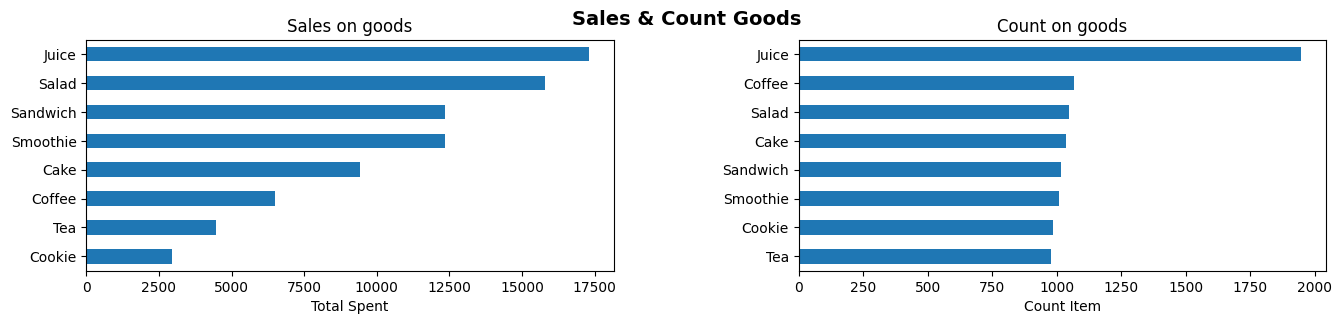

In [137]:
# Sales & Count goods
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
fig.suptitle("Sales & Count Goods", fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item
ax = axes[0]  # axes[0, 0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Sales on goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")

# count per item
ax = axes[1]  # axes[0, 1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Count on goods")
ax.set_xlabel("Count Item")
ax.set_ylabel("")

# plt.savefig('cafe_eda_1.png', dpi=150, bbox_inches='tight')

plt.show()

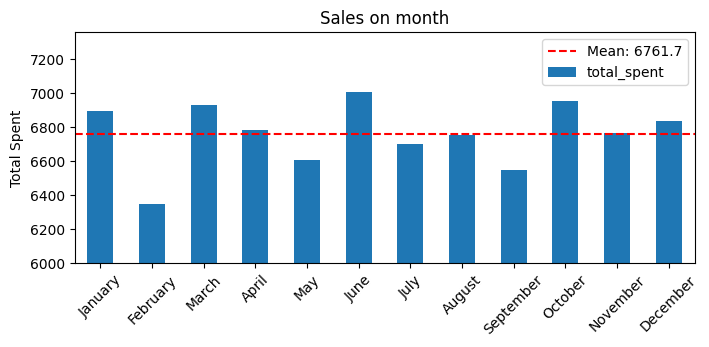

In [138]:
# Sales on month
fig = plt.figure(figsize=(8,3))
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
 ]

# print(df.groupby('month_name')['total_spent'].sum())
rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]
)

rev_month.plot(kind='bar', rot=45)


mean_value = rev_month.mean()
# std_value = rev_month.std()
# std_pct = (std_value / mean_value) * 100

plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_value:.1f}")

plt.ylim(bottom=6000)


plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
plt.legend(loc='upper right')
# plt.legend(bbox_to_anchor=(1.26, 1), loc='upper right')

# plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
#          bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
#          )

# plt.savefig('cafe_eda_2.png', dpi=150, bbox_inches='tight')
plt.show()

ДЗ: додати графіків за власним поглядом

In [139]:

# Save figure
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

##Saving a clean CSV for Tableau

In [140]:
# df['transaction_date'] = df_origin['Transaction Date'].copy()
# df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')


In [142]:
q = 0
try:
  a = 1 / 1
  q = 1
except Exception as e:
  print("Error:", e)
else:
  print("Спроба ділення")
finally:
  if q:
    print("Виконався try")
  else:
    print("Виконався except")


Спроба ділення
Виконався try


In [145]:
# For Tableau better date format: YYYY-MM-DD
try:
  df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')

except:
  print("transaction_date was change - (%Y-%m-%d)")

# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}")  # work in colab ('data/file_name.csv')
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

transaction_date was change - (%Y-%m-%d)
Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16
Columns: ['trnsaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']


## SUMMARY REPORT

In [174]:
# print(f"Total revenue: {df['total_spent'].sum():.2f}")
# print(f"Total revenue: {df['total_spent'].mean():>12,.2f}")

print(f"Total revenue:            {df['total_spent'].sum():>14,.2f}")
print(f"Number of transactions:   {len(df):>14,}")
print(f"Average check:            {df['total_spent'].mean():>14,.2f}")
print(f"Median chec:              {df['total_spent'].median():>14,.2f}")
print(f"Unique products:          {df['item'].nunique():>14,}")
print(f"Unique locations:         {df['location'].nunique():>14,}")

top_item = df.groupby('item')['total_spent'].sum().idxmax()
print(f"Top profitable product:   {top_item:>14}")

top_pay = df.loc[df['payment_method'] != "Unknown", 'payment_method'].value_counts().idxmax()
print(f"Unique payment method:    {df['payment_method'].nunique():>14,}")
print(f"Top payment method:       {top_pay:>14}")

# top_pay = df['payment_method'].value_counts()
# top_pay.drop('Unknown', errors='ignore').idxmax()

all_pay_method = df.loc[df['payment_method'] != "Unknown", 'payment_method']
print(f"Unique payment method:    {all_pay_method.nunique():>14,}")

top_pay1 = all_pay_method.value_counts().idxmax()
print(f"Top payment method:       {top_pay1:>14}")

Total revenue:                 81,140.00
Number of transactions:            9,083
Average check:                      8.93
Median chec:                        8.00
Unique products:                       8
Unique locations:                      3
Top profitable product:            Juice
Unique payment method:                 4
Top payment method:       Digital Wallet
Unique payment method:                 3
Top payment method:       Digital Wallet
